In [1]:
import pandas as pd
df = pd.read_csv("used_cars_data.csv")
df

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN


In [2]:
df = df.drop(columns=["S.No.", "Owner_Type","Seats"], errors="ignore")

In [3]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,26.6 km/kg,998 CC,58.16 bhp,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,19.67 kmpl,1582 CC,126.2 bhp,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,18.2 kmpl,1199 CC,88.7 bhp,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,20.77 kmpl,1248 CC,88.76 bhp,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,15.2 kmpl,1968 CC,140.8 bhp,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...
7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,20.54 kmpl,1598 CC,103.6 bhp,NaN,NaN
7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,17.21 kmpl,1197 CC,103.6 bhp,NaN,NaN
7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,23.08 kmpl,1461 CC,63.1 bhp,NaN,NaN
7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,17.2 kmpl,1197 CC,103.6 bhp,NaN,NaN


In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df = df.drop_duplicates()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col, unit in [("Mileage", [" kmpl", " km/kg"]), ("Engine", [" CC"]), ("Power", [" bhp"])]:
    df[col] = df[col].astype(str)
    for u in unit:
        df[col] = df[col].str.replace(u, "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,26.60,998.0,58.16,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,19.67,1582.0,126.20,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,20.77,1248.0,88.76,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,15.20,1968.0,140.80,NaN,17.74
...,...,...,...,...,...,...,...,...,...,...,...
7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,20.54,1598.0,103.60,NaN,NaN
7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,17.21,1197.0,103.60,NaN,NaN
7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,23.08,1461.0,63.10,NaN,NaN
7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,17.20,1197.0,103.60,NaN,NaN


In [9]:
df = df.dropna(subset=["Mileage", "Engine", "Power", "Price","New_Price"])

In [10]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,New_Price,Price
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50
7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,11.36,2755.0,171.50,21 Lakh,17.50
10,Maruti Ciaz Zeta,Kochi,2018,25692,Petrol,Manual,21.56,1462.0,103.25,10.65 Lakh,9.95
15,Mitsubishi Pajero Sport 4X4,Delhi,2014,110000,Diesel,Manual,13.50,2477.0,175.56,32.01 Lakh,15.00
20,BMW 3 Series 320d,Kochi,2014,32982,Diesel,Automatic,22.69,1995.0,190.00,47.87 Lakh,18.55
...,...,...,...,...,...,...,...,...,...,...,...
5999,Tata Bolt Revotron XT,Chennai,2016,10000,Petrol,Manual,17.57,1193.0,88.70,7.77 Lakh,4.00
6002,Volkswagen Vento 1.6 Highline,Mumbai,2011,38000,Petrol,Manual,16.09,1598.0,103.50,11.91 Lakh,3.25
6005,Maruti Vitara Brezza VDi,Pune,2016,37208,Diesel,Manual,24.30,1248.0,88.50,9.93 Lakh,7.43
6010,Honda Brio 1.2 VX MT,Delhi,2013,33746,Petrol,Manual,18.50,1198.0,86.80,6.63 Lakh,3.20


In [11]:
    def remove_outliers_iqr(data, column):
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        return data[(data[column] >= lower) & (data[column] <= upper)]
    for col in ["Kilometers_Driven", "Mileage", "Engine", "Power", "Price"]:
        df = remove_outliers_iqr(df, col)

In [12]:
df

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,New_Price,Price
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,18.20,1199.0,88.70,8.61 Lakh,4.50
7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,11.36,2755.0,171.50,21 Lakh,17.50
10,Maruti Ciaz Zeta,Kochi,2018,25692,Petrol,Manual,21.56,1462.0,103.25,10.65 Lakh,9.95
20,BMW 3 Series 320d,Kochi,2014,32982,Diesel,Automatic,22.69,1995.0,190.00,47.87 Lakh,18.55
28,Honda WRV i-VTEC VX,Kochi,2018,37430,Petrol,Manual,17.50,1199.0,88.70,10.57 Lakh,9.90
...,...,...,...,...,...,...,...,...,...,...,...
5999,Tata Bolt Revotron XT,Chennai,2016,10000,Petrol,Manual,17.57,1193.0,88.70,7.77 Lakh,4.00
6002,Volkswagen Vento 1.6 Highline,Mumbai,2011,38000,Petrol,Manual,16.09,1598.0,103.50,11.91 Lakh,3.25
6005,Maruti Vitara Brezza VDi,Pune,2016,37208,Diesel,Manual,24.30,1248.0,88.50,9.93 Lakh,7.43
6010,Honda Brio 1.2 VX MT,Delhi,2013,33746,Petrol,Manual,18.50,1198.0,86.80,6.63 Lakh,3.20


In [13]:
df.to_csv("cleaned_used_cars.csv", index=False)

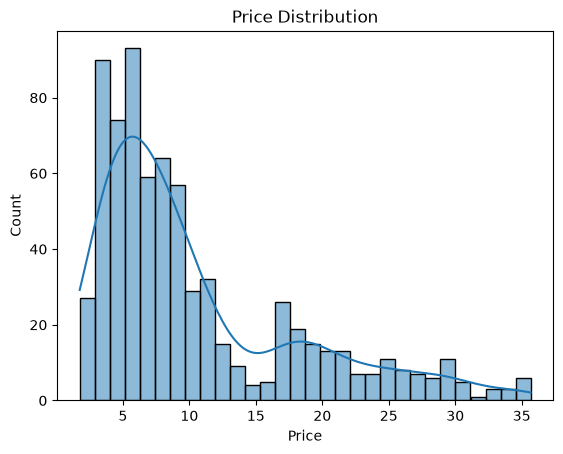

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Price'], kde=True, bins=30)
plt.title("Price Distribution")
plt.show()

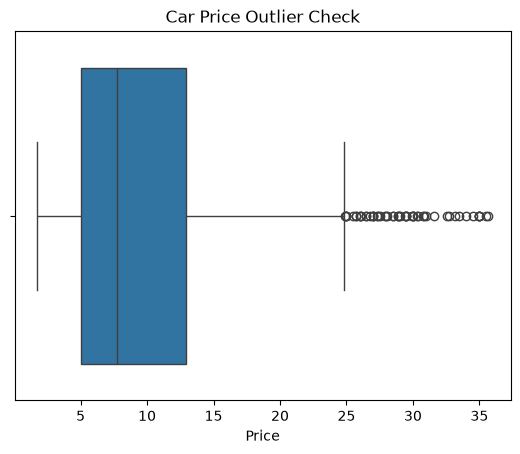

In [19]:
sns.boxplot(x=df['Price'])
plt.title("Car Price Outlier Check")
plt.show()

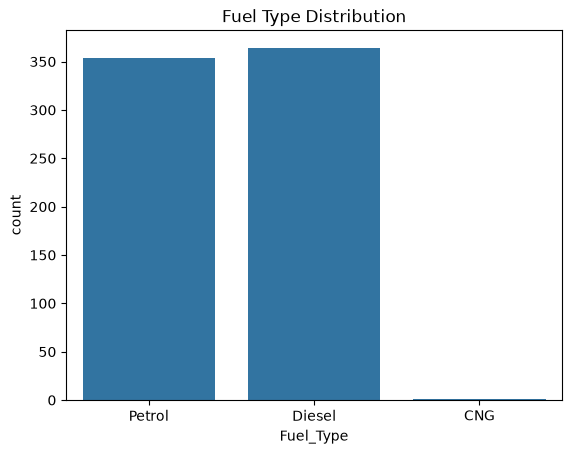

In [20]:
sns.countplot(x='Fuel_Type', data=df)
plt.title("Fuel Type Distribution")
plt.show()